In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
ticker = "AAPL"
start_date = "2022-01-01"
end_date = "2024-12-31"

data = yf.download(ticker, start=start_date, end=end_date)
data = data[["Close"]].dropna()
data.head()



/tmp/ipython-input-3356729657.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2022-01-03,178.270325
2022-01-04,176.007812
2022-01-05,171.325989
2022-01-06,168.466003
2022-01-07,168.632492


In [ ]:
data["Log_Returns"] = np.log(data["Close"] / data["Close"].shift(1))
returns = data["Log_Returns"].dropna()
returns.head()


,Log_Returns
Date,
2022-01-04,-0.012773
2022-01-05,-0.026960
2022-01-06,-0.016834
2022-01-07,0.000988
2022-01-10,0.000116


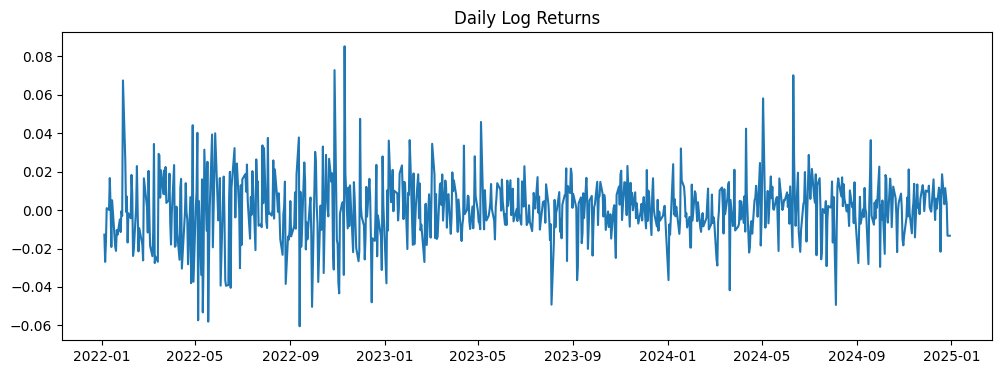

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(returns)
plt.title("Daily Log Returns")
plt.show()


In [ ]:
hist_vol = returns.std() * np.sqrt(252)
hist_vol


np.float64(0.27061269753874645)

In [ ]:
data["Vol_20"] = returns.rolling(20).std() * np.sqrt(252)
data["Vol_60"] = returns.rolling(60).std() * np.sqrt(252)
data["Vol_120"] = returns.rolling(120).std() * np.sqrt(252)

data[["Vol_20", "Vol_60", "Vol_120"]].dropna().head()


Price,Vol_20,Vol_60,Vol_120
Ticker,,,
Date,,,
2022-06-27,0.407446,0.410375,0.359065
2022-06-28,0.390290,0.412957,0.361055
2022-06-29,0.394979,0.414388,0.359891
2022-06-30,0.398316,0.411513,0.360016
2022-07-01,0.397880,0.412452,0.360930


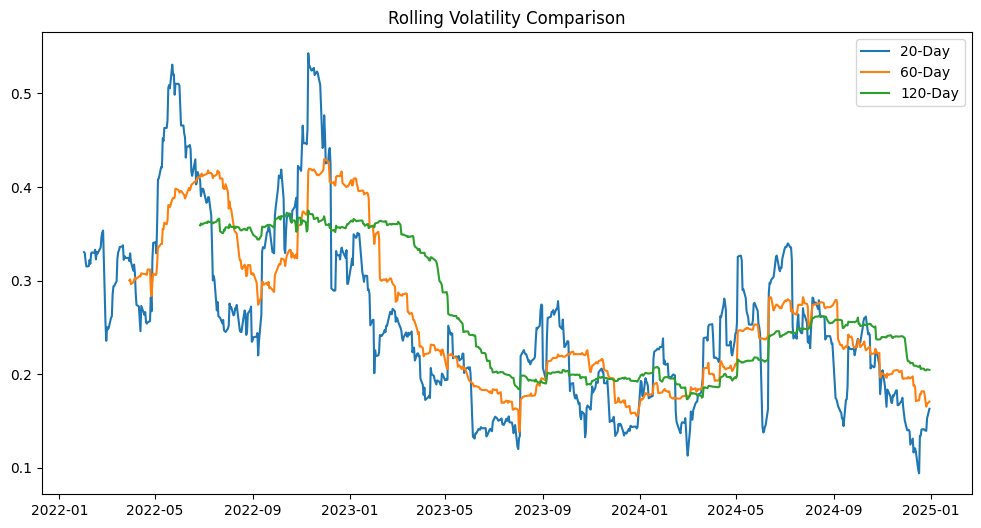

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(data["Vol_20"], label="20-Day")
plt.plot(data["Vol_60"], label="60-Day")
plt.plot(data["Vol_120"], label="120-Day")
plt.legend()
plt.title("Rolling Volatility Comparison")
plt.show()


In [ ]:
def ewma_volatility(returns, lam=0.94):
    weights = np.array([(1 - lam) * lam**i for i in range(len(returns))])[::-1]
    weights = weights / weights.sum()
    return np.sqrt(np.sum(weights * returns.values**2)) * np.sqrt(252)


In [ ]:
ewma_vol = ewma_volatility(returns)
ewma_vol


np.float64(0.17164752597607558)

In [ ]:
pd.DataFrame({
    "Historical Volatility": [hist_vol],
    "EWMA Volatility": [ewma_vol]
})


,Historical Volatility,EWMA Volatility
0,0.270613,0.171648


In [ ]:
event_date = pd.to_datetime("2023-06-13")
window = 10


In [ ]:
before_event = returns.loc[event_date - pd.Timedelta(days=window):event_date]
after_event = returns.loc[event_date:event_date + pd.Timedelta(days=window)]

vol_before = before_event.std() * np.sqrt(252)
vol_after = after_event.std() * np.sqrt(252)

pd.DataFrame({
    "Before Event Volatility": [vol_before],
    "After Event Volatility": [vol_after]
})


,Before Event Volatility,After Event Volatility
0,0.156945,0.127466


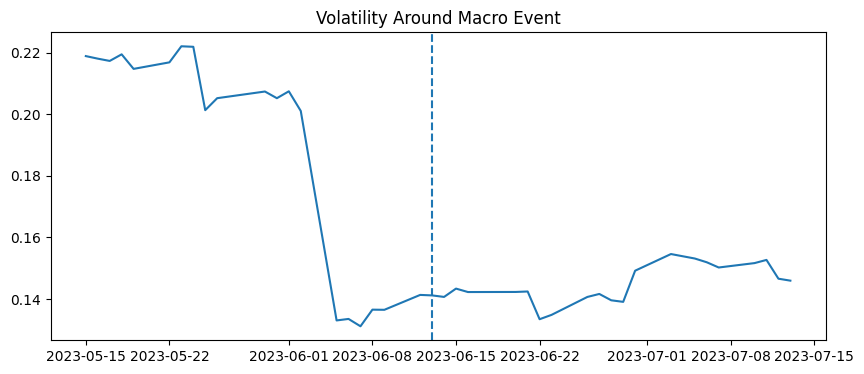

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(data.loc[event_date - pd.Timedelta(days=30):event_date + pd.Timedelta(days=30), "Vol_20"])
plt.axvline(event_date, linestyle="--")
plt.title("Volatility Around Macro Event")
plt.show()


In [ ]:
summary = pd.DataFrame({
    "Metric": ["Historical Vol", "EWMA Vol", "Pre-Event Vol", "Post-Event Vol"],
    "Value": [hist_vol, ewma_vol, vol_before, vol_after]
})
summary


,Metric,Value
0,Historical Vol,0.270613
1,EWMA Vol,0.171648
2,Pre-Event Vol,0.156945
3,Post-Event Vol,0.127466
